In [1]:
from tools.profiler import profile_dataframe

In [2]:
profile_dataframe("test_data/Train_Set_90621.parquet")

{'shape': (195118, 29),
 'columns': ['Application ID',
  'Bank Masked',
  'Bank Type',
  'Approved_Timestamp',
  'Name Masked',
  'Business Owner State',
  'Business_Industry_Type_Code',
  'Approved_Year',
  'New Business',
  'Term',
  'BankState',
  'Interest Rate',
  'Employees',
  'Gross Disbursed Amount',
  'Term_years',
  'Jobs Retained',
  'Male to Female Employees Ratio',
  'Expected Company Income',
  'Funds available with company',
  'Gross_Apprv_Amount',
  'Company Branch Code',
  'City or Rural',
  'Jobs Generated',
  'Carry-forward Credit',
  'Documents Provided',
  'Balance Left',
  'Amount Defaulted',
  'Final_Appved_Amount',
  'Default_Status'],
 'dtypes': {'Application ID': dtype('int64'),
  'Bank Masked': <StringDtype(na_value=nan)>,
  'Bank Type': <StringDtype(na_value=nan)>,
  'Approved_Timestamp': <StringDtype(na_value=nan)>,
  'Name Masked': <StringDtype(na_value=nan)>,
  'Business Owner State': <StringDtype(na_value=nan)>,
  'Business_Industry_Type_Code': dtype('i

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage
from agents.analyst import analyst_node
from graph.agent_state import AgentState

In [ ]:
from pydantic import BaseModel, Field
from graph.agent_state import AgentState
from tools.profiler import profile_dataframe
from llm import llm
from langchain_core.prompts import ChatPromptTemplate
from enum import Enum
from langchain_core.messages import AIMessage


class TaskType(str, Enum):
    CLASSIFICATION = "classification"
    REGRESSION = "regression"

class AnalysisResult(BaseModel):
    task_type: TaskType = Field(description="Тип решаемой задачи для разработки модели")
    target_column: str = Field(description="Поле, которое в датафрейме отвечает за target - предсказываемое значение")
    problem_description: str = Field(description="Общее резюме решаемой задачи и имеющихся данных")
    data_issues: list[str] = Field(description="Описание найденных проблем в данных: пропуски, выбросы и т.д.")

analyst = ChatPromptTemplate.from_messages([
        ("system", 
     """
    Ты аналитик Data Science, твоя задача понять задачу, которую
    необходимо решить из описания пользователя и проанализировать датасет
    на основе предоставленных статистик.

    1. Определи task_type - тип рещаемой задачи, может принимать значения 'classification', 'regression'
    2. Определи target_column - колонка, которую нужно предсказывать. Нужно найти в описании задачи, этот вариант самый приоритетный.
    Если нет в описании, то найти поле 'target' в списке колонок. В противном случае ничего не вернуть.
    3. Определи problem_description - 2-3 предложения, описывающих решаемую задачу и предоставленные данные
    4. Определи data_issues - список найденны проблем (пропуски в данных более чем в 90% случаев, типы переменных, вероятные колонки-идентификаторы)

    ВАЖНО: ничего не придумывай, используй имена колонок из предоставленного profile
    """),
    ("system", 
    """
         Профиль данных:
         - shape: {{ profile.shape }}
         - columns: {{ profile.columns | join(', ') }}
         - dtypes: {{ profile.dtypes }}
         - na_stat: {{ profile.na_stat }}
         - head: {{ profile.head }}
     """),
    ("human", "Описание от пользователя: {query}")
],
template_format="jinja2"
) | llm.with_structured_output(AnalysisResult)

def analyst_node(state: AgentState) -> dict:
    messages = state["messages"]
    last_message = messages[-1].content
    profile = profile_dataframe(state["file_path"])
    result = analyst.invoke({"profile": profile, "query": last_message})
    return {
        "messages": [AIMessage(content=result.problem_description)],
        "analysis_result": result
    }

In [ ]:
from pydantic import BaseModel, Field
from graph.agent_state import AgentState
from llm import llm
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage

class AnalysisResult(BaseModel):
    id_columns: list[str] = Field(description="Список колонок, которые потенциально являются идентификаторами")
    date_string: list[str] = Field(description="Список колонок, которые являтся датами, но хранятся в формате str")
    high_missing_columns: dict = Field(description="Список колонок с высоким порогом")
    categorica_columns: list[str] = Field(description="Список колонок, которые являются категориальными переменными")

In [2]:
builder = StateGraph(AgentState)

builder.add_node("analyst_node", analyst_node)

builder.add_edge(START, "analyst_node")
builder.add_edge("analyst_node", END)

graph = builder.compile()

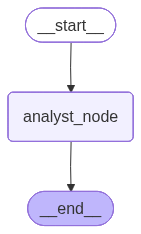

In [3]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_ascii())

In [4]:
query = """
    Во вложении датасет, который описывает данные банковских клиентов.
    Необходимо решить задачу бинарной классификации, таргетом выступает столбец Default_Status
    Уникальный идентификатор клиента - Application ID
"""

graph = builder.compile()

result = graph.invoke(
    {"messages": [HumanMessage(content=query)], "file_path": "test_data/Train_Set_90621.parquet"},
    config={"configurable": {"thread_id": "test_routing"}}
)

In [5]:
result

{'messages': [HumanMessage(content='\n    Во вложении датасет, который описывает данные банковских клиентов.\n    Необходимо решить задачу бинарной классификации, таргетом выступает столбец Default_Status\n    Уникальный идентификатор клиента - Application ID\n', additional_kwargs={}, response_metadata={}, id='5acbb9e0-9a22-4f10-804a-393942b6797a'),
  AIMessage(content='По данным заявок на бизнес-кредит требуется предсказывать вероятность/класс дефолта по заявке. Датасет содержит параметры банка и заемщика (тип банка, штат, отраслевой код, сумма, срок, занятость, документы и т.п.), а также целевую метку Default_Status.', additional_kwargs={}, response_metadata={}, id='f140da8d-df2a-4dd7-9b67-17efb1bf963f', tool_calls=[], invalid_tool_calls=[])],
 'file_path': 'test_data/Train_Set_90621.parquet',
 'analysis_result': AnalysisResult(task_type=<TaskType.CLASSIFICATION: 'classification'>, target_column='Default_Status', problem_description='По данным заявок на бизнес-кредит требуется предск

In [10]:
print(result['analysis_result'].data_issues)

['Пропуски присутствуют, но доля пропусков по всем колонкам существенно ниже 90% (максимум около 0.5% для Carry-forward Credit).', "Категориальные признаки представлены строками (например, 'Bank Masked', 'Bank Type', 'Name Masked', 'Business Owner State', 'BankState', 'Carry-forward Credit', 'Documents Provided'), потребуется кодирование.", "Вероятные идентификаторы: 'Application ID' (int64) и 'Company Branch Code' (int64) — могут нести уникальную/служебную информацию и требовать аккуратной обработки.", "'Approved_Timestamp' имеет тип str (формат даты в строке), потребуется парсинг в datetime для корректного использования.", "Целевая колонка 'Default_Status' имеет тип int64 (возможна бинарность/классы, но по профилю это не подтверждено)."]


In [1]:
import pandas as pd
from settings import Settings

In [2]:
settings = Settings()

In [3]:
df = pd.read_parquet("test_data/Train_Set_90621.parquet")

In [4]:
def extended_profile(
        df: pd.DataFrame, target_column: str,
          task_type: str, threshold: float = settings.na_threshold
          ):
    pass



In [ ]:
extended_profile(df, target_column, task_type, threshold=0.9) -> dict

<enum 'TaskType'>